In [9]:
from Scene_lib2 import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
import pickle

In [ ]:
import os
import numpy as np

ns = np.arange(start=50, stop=1501, step=50)
categories = ['Measured']
noise_levels = [0.]
base_dir = '3D-Data'
h = 3.5
boundary = [[-4,4],[-4,4],[0,h]]

# Generate 10 datasets with different seeds
num_seeds = 10

for category in categories:
    for noise_level in noise_levels:
        for n in ns:
            for seed in range(num_seeds):  # Iterate over 10 seeds (0 to 9)
                my_scene = Scene()
                use_measured_data = (category == 'Measured')

                my_scene.generate_sven_lights(use_measured_data=use_measured_data)
                my_scene.generate_diode_plane(n=2)
                my_scene.generate_diode_plane(n=2, h=h)
                my_scene.generate_diode_halton_volume(n=n-8, volume_boundary=[[-4,4],[-4,4],[0,h]], seed=seed)

                data = my_scene.generate_rss_table_with_diode_coords(noise_std=noise_level, seed=seed)
                print(data)

                # Create category folder if it doesn’t exist
                category_dir = os.path.join(base_dir, category)
                os.makedirs(category_dir, exist_ok=True)

                # Save the dataset with seed info in filename
                file_name = f"rss_n={n}_noise={noise_level}_seed={seed}.csv"
                file_path = os.path.join(category_dir, file_name)
                
                data.to_csv(file_path, index=False)
                print(f"Saved data for {category} (n={n}, noise={noise_level}, seed={seed}) to {file_path}")

             RSS0      RSS1      RSS2      RSS3      RSS4      X         Y  \
Diode0   0.002773  0.008007  0.002214  0.002144  0.000952   -4.0      -4.0   
Diode1   0.002779  0.002116  0.000971  0.008115   0.00216    4.0      -4.0   
Diode2    0.00274  0.002115  0.007736  0.000892  0.002121   -4.0       4.0   
Diode3   0.002742   0.00092  0.002094  0.002054  0.007924    4.0       4.0   
Diode4   0.000328  0.007361   0.00026  0.000182  0.000018   -4.0      -4.0   
Diode5   0.000271  0.000123  0.000019  0.007723  0.000141    4.0      -4.0   
Diode6   0.000244  0.000111  0.006798  0.000005  0.000139   -4.0       4.0   
Diode7   0.000233   0.00001  0.000092  0.000024  0.007106    4.0       4.0   
Diode8   0.002773  0.008007  0.002214  0.002144  0.000952   -4.0      -4.0   
Diode9   0.015366  0.012176  0.006015   0.01194  0.005838    0.0 -1.333333   
Diode10  0.012827   0.00796  0.024736  0.002796   0.00537   -2.0  1.333333   
Diode11  0.006264   0.00455  0.001155  0.031782  0.002521    2.0

In [11]:
ns= np.array([50])
categories=['Measured']
noise_levels= [0.,0.000006, 0.000019,0.00006,0.00019]
base_dir='3D-Data'
# test data creation on dense grid
for category in categories:
    for noise_level in noise_levels:
        for n in ns:
            my_scene=Scene()
            use_measured_data= (category =='Measured')
            my_scene.generate_sven_lights(use_measured_data=use_measured_data)
            my_scene.generate_diode_volume(n=n,volume_boundary=[[-4,4],[-4,4],[0,h]])
            data= my_scene.generate_rss_table_with_diode_coords(noise_std=noise_level,seed=0)
            category_dir= os.path.join(base_dir,category)
            os.makedirs(category_dir,exist_ok=True)
            file_name= f"gnd_n={n}_noise={noise_level}.csv"
            file_path = os.path.join(category_dir, file_name)
            data.to_csv(file_path, index=False)
            print(f"Saved data for {category} (n={n}, noise={noise_level}) to {file_path}")

Saved data for Measured (n=50, noise=0.0) to 3D-Data\Measured\gnd_n=50_noise=0.0.csv
Saved data for Measured (n=50, noise=6e-06) to 3D-Data\Measured\gnd_n=50_noise=6e-06.csv
Saved data for Measured (n=50, noise=1.9e-05) to 3D-Data\Measured\gnd_n=50_noise=1.9e-05.csv
Saved data for Measured (n=50, noise=6e-05) to 3D-Data\Measured\gnd_n=50_noise=6e-05.csv
Saved data for Measured (n=50, noise=0.00019) to 3D-Data\Measured\gnd_n=50_noise=0.00019.csv


In [12]:
# data = 
base_dir="3D-Data"
category = "Measured"
n= 50
noise_level= 0.
scaler_filename = "scaler_absolute.pkl"


category_dir= os.path.join(base_dir,category)
file_name= f"gnd_n={n}_noise={noise_level}.csv"
file_path = os.path.join(category_dir, file_name)
data= pd.read_csv(file_path)
columns= data.columns


regenerate_scaler = True
if regenerate_scaler:
    scaler = StandardScaler()
    scaler.fit(data.values)
    with open(scaler_filename, "wb") as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved as '{scaler_filename}'")
else:
    with open(scaler_filename,"rb") as f:
        loaded_scaler = pickle.load(f)
print(scaler.mean_)
print(scaler.scale_)
pd.DataFrame(scaler.transform(data.values),columns= columns)

Scaler saved as 'scaler_absolute.pkl'
[ 1.09524094e-02  9.17186376e-03  9.24327883e-03  9.04984054e-03
  9.18506658e-03 -2.31011654e-16 -3.49245965e-16  1.75000000e+00]
[0.01128293 0.01213571 0.01200425 0.01207162 0.01202347 2.35606036
 2.35606036 1.03077641]


,RSS0,RSS1,RSS2,RSS3,RSS4,X,Y,Z
0,-0.724896,-0.095959,-0.585585,-0.572112,-0.684746,-1.697749,-1.697749,-1.697749
1,-0.725668,-0.085893,-0.586841,-0.573301,-0.686017,-1.697749,-1.697749,-1.628453
2,-0.726561,-0.075708,-0.588159,-0.574589,-0.687341,-1.697749,-1.697749,-1.559158
3,-0.727559,-0.065410,-0.589550,-0.575948,-0.688708,-1.697749,-1.697749,-1.489862
4,-0.728677,-0.055003,-0.591086,-0.577451,-0.690095,-1.697749,-1.697749,-1.420566
...,...,...,...,...,...,...,...,...
124995,-0.928422,-0.753226,-0.751278,-0.742152,-0.021832,1.697749,1.697749,1.420566
124996,-0.934350,-0.753793,-0.754474,-0.744235,-0.054312,1.697749,1.697749,1.489862
124997,-0.939959,-0.754311,-0.757365,-0.745751,-0.090049,1.697749,1.697749,1.559158
124998,-0.945173,-0.754639,-0.760034,-0.746976,-0.129293,1.697749,1.697749,1.628453


In [13]:

base_dir = "3D-Data"
category = "Measured"
normalized_category = "Measured_Normalized"
scaler_filename = "scaler_absolute.pkl"

# Paths for original and normalized data
category_dir = os.path.join(base_dir, category)
normalized_category_dir = os.path.join(base_dir, normalized_category)

# Ensure the normalized folder exists
os.makedirs(normalized_category_dir, exist_ok=True)

# Load the precomputed scaler
with open(scaler_filename, "rb") as f:
    loaded_scaler = pickle.load(f)
print(f"Loaded scaler from '{scaler_filename}'")

# Iterate over all CSV files in the Measured folder
for file_name in os.listdir(category_dir):
    if file_name.endswith(".csv"):  # Process all CSV files
        file_path = os.path.join(category_dir, file_name)
        data = pd.read_csv(file_path)

        # Normalize the data
        normalized_data = pd.DataFrame(loaded_scaler.transform(data.values), columns=data.columns)

        # Save the normalized data to the separate Measured_Normalized folder
        normalized_file_path = os.path.join(normalized_category_dir, file_name)
        normalized_data.to_csv(normalized_file_path, index=False)

        print(f"Saved normalized data to {normalized_file_path}")


Loaded scaler from 'scaler_absolute.pkl'
Saved normalized data to 3D-Data\Measured_Normalized\gnd_n=50_noise=0.0.csv
Saved normalized data to 3D-Data\Measured_Normalized\gnd_n=50_noise=0.00019.csv
Saved normalized data to 3D-Data\Measured_Normalized\gnd_n=50_noise=1.9e-05.csv
Saved normalized data to 3D-Data\Measured_Normalized\gnd_n=50_noise=6e-05.csv
Saved normalized data to 3D-Data\Measured_Normalized\gnd_n=50_noise=6e-06.csv
Saved normalized data to 3D-Data\Measured_Normalized\rss_n=1000_noise=0.0_seed=0.csv
Saved normalized data to 3D-Data\Measured_Normalized\rss_n=1000_noise=0.0_seed=1.csv
Saved normalized data to 3D-Data\Measured_Normalized\rss_n=1000_noise=0.0_seed=2.csv
Saved normalized data to 3D-Data\Measured_Normalized\rss_n=1000_noise=0.0_seed=3.csv
Saved normalized data to 3D-Data\Measured_Normalized\rss_n=1000_noise=0.0_seed=4.csv
Saved normalized data to 3D-Data\Measured_Normalized\rss_n=1000_noise=0.0_seed=5.csv
Saved normalized data to 3D-Data\Measured_Normalized\rss_

Selected file for visualization: 3D-Data/Measured_Normalized\rss_n=1400_noise=0.0_seed=5.csv


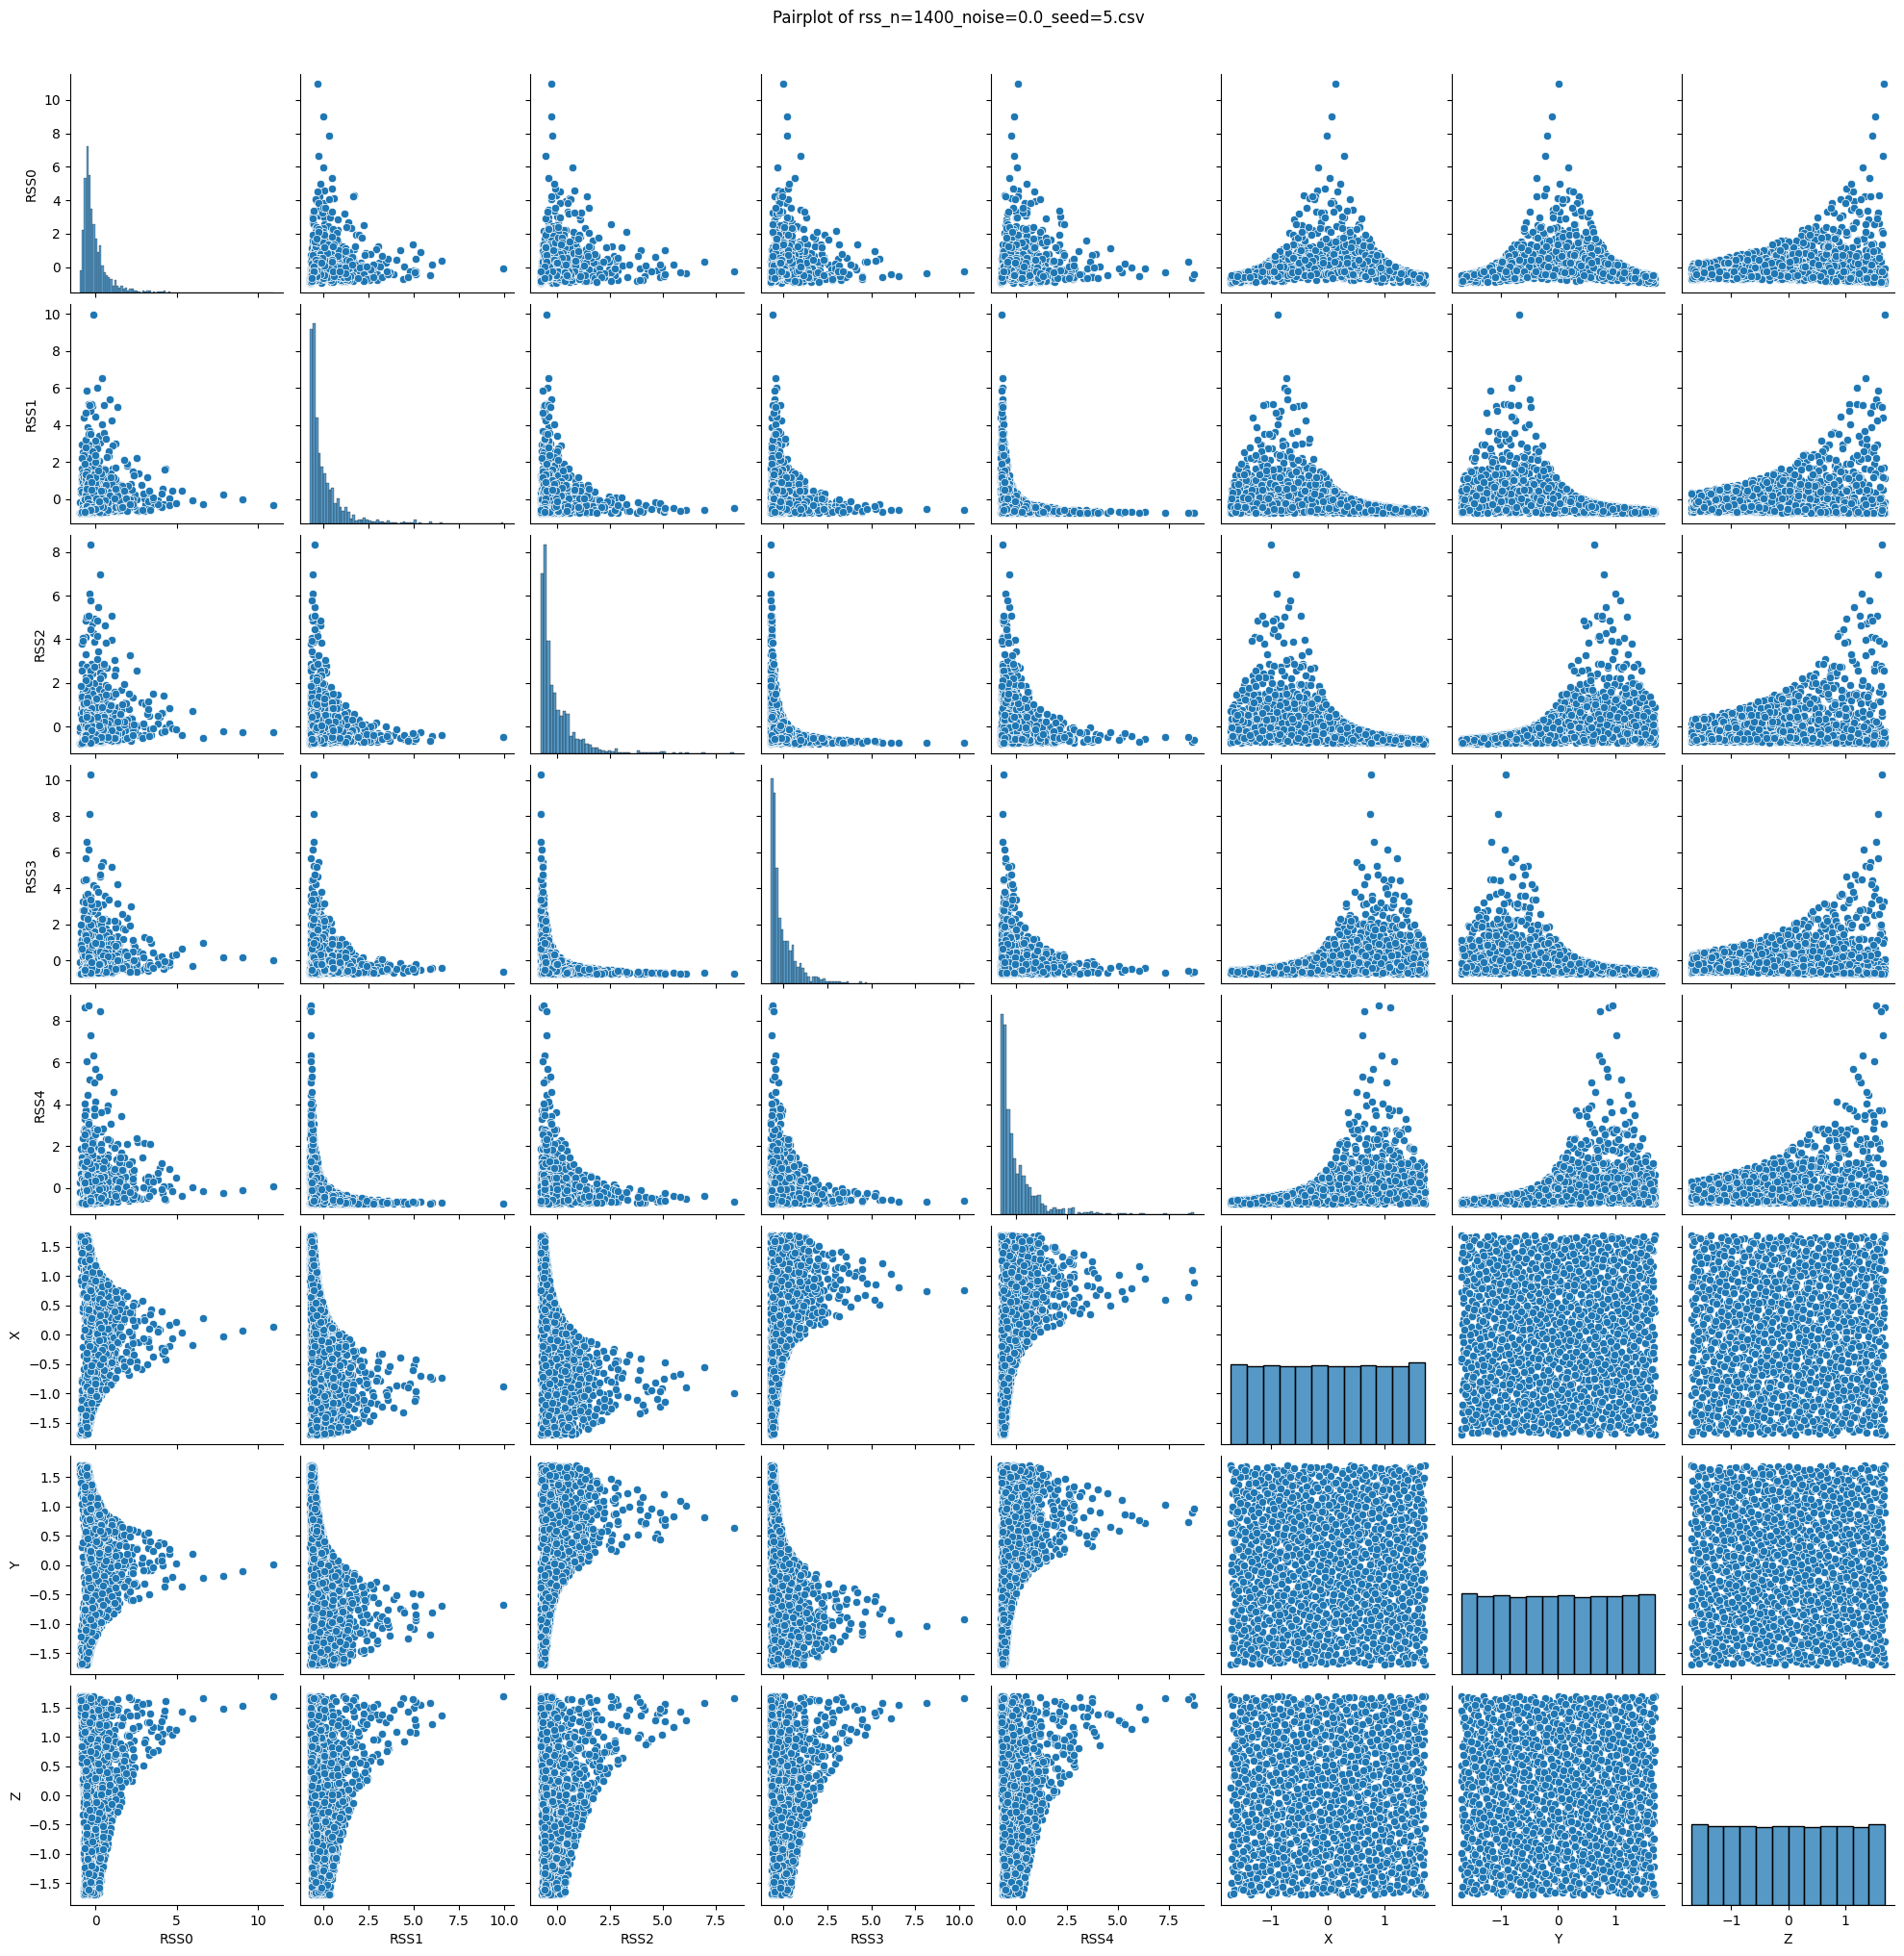

In [15]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the path to the normalized data directory
normalized_category_dir = "3D-Data/Measured_Normalized"

# Get a list of all normalized CSV files
normalized_files = [f for f in os.listdir(normalized_category_dir) if f.endswith(".csv")]

# Pick one file (arbitrarily the first one in the list)
if normalized_files:
    selected_file = os.path.join(normalized_category_dir, normalized_files[100])
    print(f"Selected file for visualization: {selected_file}")

    # Load the dataset
    data = pd.read_csv(selected_file)

    # Create a pairplot
    sns.pairplot(data)
    plt.suptitle(f"Pairplot of {normalized_files[100]}", y=1.02)
    plt.show()
else:
    print("No normalized CSV files found in the directory.")
